# Week 4 Assignment: VAE & Diffusion 실습

**24th Computer Vision Basic Session / KUBIG / made by Sehun Lee**

---

강의에서 다룬 내용을 코드로 직접 확인해 보는 과제입니다.
`TODO`로 비어 있는 부분을 채우고, 노트북을 위에서부터 아래까지 **끊김 없이 실행**한 뒤
출력 결과가 남아 있는 상태로 제출하세요.

### 채워야 할 빈칸 (총 8개)

| 번호 | 위치 | 내용 |
|---|---|---|
| TODO 1 | `VAE.__init__` | encoder가 `mu`, `logvar`를 내보내는 layer 정의 |
| TODO 2 | `VAE.reparameterize` | Reparameterization trick |
| TODO 3 | `vae_loss` | ELBO (Reconstruction + KL) |
| TODO 4 | VAE Sampling | prior에서 뽑아 decoder로 생성 |
| TODO 5 | Diffusion Schedule | `alphas`, `alphas_cumprod` |
| TODO 6 | `q_sample` | Forward process (closed form) |
| TODO 7 | `diffusion_loss` | Noise prediction loss |
| TODO 8 | `p_sample` | Reverse denoising 한 스텝 |

마지막의 **서술형 질문 2개**도 함께 답변해 주세요.

### 제출
- 실행 결과가 포함된 `.ipynb` 파일
- `KUBIG_26_FALL/Basic Study/CV/week4`
- 마감: 8/5(수) 자정

## 0. 환경 설정

Colab 기준으로 작성되었습니다. GPU 런타임(T4 이상)을 권장하지만 CPU에서도 동작합니다.
CPU라면 아래 설정 셀에서 `SUBSET_SIZE`와 `EPOCHS`를 줄이세요.

In [1]:
import math
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.8.0+cu128
device: cuda


In [2]:
SEED = 42

# CPU 환경이면 SUBSET_SIZE = 10000, EPOCHS를 3~5 정도로 줄이는 것을 권장
SUBSET_SIZE = None      # None이면 MNIST 전체(60,000장) 사용
BATCH_SIZE = 128

VAE_EPOCHS = 10
VAE_LATENT_DIM = 16

DIFF_EPOCHS = 10
DIFF_TIMESTEPS = 300

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


def show_images(tensor, title="", nrow=8):
    # tensor: (B, 1, 28, 28), 값 범위는 [0, 1]로 맞춰서 넣을 것
    grid = make_grid(tensor.detach().cpu().clamp(0, 1), nrow=nrow, padding=2)
    plt.figure(figsize=(nrow, tensor.size(0) / nrow + 1))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

## 1. 데이터

MNIST를 사용합니다. 두 모델이 요구하는 값의 범위가 다르다는 점에 주의하세요.

- **VAE**: 픽셀을 Bernoulli 확률로 보고 `sigmoid` + BCE를 씁니다. `[0, 1]`
- **Diffusion**: Gaussian noise를 더하고 빼므로 0을 중심으로 대칭인 `[-1, 1]`

100%|██████████| 9.91M/9.91M [00:00<00:00, 130MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 25.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 262MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


train size: 60000 | batches: 468


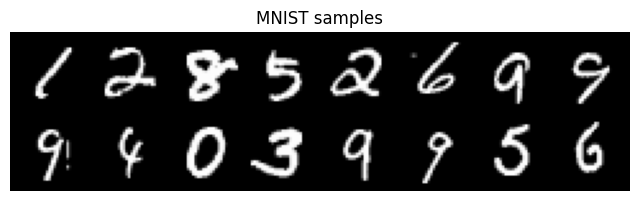

In [3]:
tf_01 = transforms.ToTensor()                      # [0, 1]
tf_11 = transforms.Compose([                       # [-1, 1]
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_01 = datasets.MNIST(root="./data", train=True, download=True, transform=tf_01)
train_11 = datasets.MNIST(root="./data", train=True, download=True, transform=tf_11)
test_01 = datasets.MNIST(root="./data", train=False, download=True, transform=tf_01)

if SUBSET_SIZE is not None:
    idx = torch.randperm(len(train_01))[:SUBSET_SIZE].tolist()
    train_01 = Subset(train_01, idx)
    train_11 = Subset(train_11, idx)

vae_loader = DataLoader(train_01, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
diff_loader = DataLoader(train_11, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_01, batch_size=BATCH_SIZE, shuffle=False)

print("train size:", len(train_01), "| batches:", len(vae_loader))

sample_x, _ = next(iter(vae_loader))
show_images(sample_x[:16], title="MNIST samples", nrow=8)

---
# Part 1. Variational Autoencoder

## 1-1. 무엇을 구현하는가

Encoder $q_\phi(z|x)$는 입력마다 하나의 점이 아니라 **분포**(평균 $\mu$, 분산 $\sigma^2$)를 내놓습니다.
그 분포에서 뽑은 $z$를 Decoder $p_\theta(x|z)$가 다시 이미지로 되돌립니다.

목적함수는 강의에서 본 ELBO입니다.

$$
\log p_\theta(x) \;\ge\; \mathbb{E}_{q_\phi(z|x)}\left[\log p_\theta(x|z)\right] \; - \; \mathrm{KL}\!\left(q_\phi(z|x) \,\|\, p(z)\right)
$$

이걸 최소화 문제로 바꾸면 loss는 다음 두 항의 합이 됩니다. (여러분이 유도하신 대로..)

$$
\mathcal{L}_{\text{VAE}} = \underbrace{-\mathbb{E}_{q_\phi(z|x)}\left[\log p_\theta(x|z)\right]}_{\text{Reconstruction}} + \underbrace{\mathrm{KL}\!\left(q_\phi(z|x)\,\|\,p(z)\right)}_{\text{Regularization}}
$$

$q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2 I)$, $p(z) = \mathcal{N}(0, I)$일 때 KL 항은 closed form으로 떨어집니다.

$$
\mathrm{KL} = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)
$$

## 1-2. TODO 1, 2: 모델

- **TODO 1**: encoder hidden에서 `mu`와 `logvar`를 각각 뽑는 layer를 정의하세요.
  `sigma`를 직접 예측하지 않고 `logvar`를 예측하는 이유를 생각해 보세요 (양수 제약, 수치 안정성).
- **TODO 2**: Reparameterization trick.
  $z = \mu + \sigma \odot \epsilon,\;\; \epsilon \sim \mathcal{N}(0, I)$
  `logvar`에서 `sigma`를 복원하는 과정이 필요합니다.

In [4]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=VAE_LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.enc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        # ------------------------------------------------------------------
        # TODO 1: encoder hidden(hidden_dim) -> mu, logvar (각각 latent_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
    
        # ------------------------------------------------------------------
        '''sigma가 아니라 logvar을 예측하는 이유?
        1. 양수제약: sigma는 항상 양수여야하는데, nn.Linear의 출력은 실수전체 범위라 이걸 그대로 sigma로 쓰면 학습 중에 음수가 나올수도 있다.
        반면 logvar = log(sigma^2)는 실수 전체를 값으로 가질 수 있으므로 신경망의 unconstrined 출력과 맞아떨어진다.
        이후 sigma를 구하기 위해선 exp(0.5*logvar)로 변환하면 된다(양수보장)
        2. 수치 안정성: sigma를 직접 예측하면 0근처에서 분산이 매우 작아지거나 sigma^2 계산할 때 underflow/overflow 발생 쉬움.
        log space에서 다루면 스케일이 훨씬 안정적이고, KL divergence 공식에도 로그항이 그대로 들어가서 자연스러움.
        '''

        # Decoder
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            # 출력에 sigmoid를 붙이지 않는다. loss에서 BCEWithLogits를 사용할 것이므로
            # 여기서는 logit을 그대로 내보낸다.
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # ------------------------------------------------------------------
        # TODO 2: z = mu + sigma * eps,  eps ~ N(0, I)
        # 힌트: sigma = exp(0.5 * logvar), eps는 torch.randn_like 사용
        sigma = torch.exp(0.5*logvar) # sigma 복원
        eps = torch.rand_like(sigma) # 노이즈 샘플링
        return mu + sigma*eps
        
        # ------------------------------------------------------------------
        '''
        노이즈를 분리해서 뽑는 reparamterization trick의 목적은
        z를 mu, sigma에서 직접샘플링 eps = torch.normal(mu,sigma)처럼 하면 그 샘플링 연산 자체를 미분 불가능해서 backprop이 끊기기 때문이다.
        randomness를 eps라는 외부변수로 분리해두면 z = mu + sigma*eps에서 mu와 sigma에 대해 완전히 미분 가능한 연산이 되어 encoder까지 gradient가 흘러들어간다.
        '''
        

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        # x: (B, 1, 28, 28)
        x_flat = x.view(x.size(0), -1)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        x_logit = self.decode(z)
        return x_logit, mu, logvar

## 1-3. TODO 3: ELBO Loss

- Reconstruction 항은 픽셀별 Bernoulli log-likelihood로 계산합니다.
  `F.binary_cross_entropy_with_logits(x_logit, x_target, reduction="sum")`을 쓰면
  $-\log p_\theta(x|z)$가 바로 나옵니다.
- KL 항은 위의 closed form을 그대로 옮기면 됩니다.
- 두 항 모두 **배치 전체에 대해 sum**한 뒤, 마지막에 배치 크기로 나눠 샘플당 평균으로 반환하세요.
  (sum과 mean을 섞으면 두 항의 가중치가 달라져 학습이 이상해집니다. 왜 그런지 생각해 보세요.)

In [5]:
def vae_loss(x_logit, x_target, mu, logvar):
    # x_logit:  (B, 784) decoder가 뱉은 logit
    # x_target: (B, 784) 원본 이미지, [0, 1]
    # 반환: (total_loss, recon_loss, kl_loss)  -- 모두 샘플당 평균값
    B = x_target.size(0)

    # ------------------------------------------------------------------
    # TODO 3
    recon = F.binary_cross_entropy_with_logits(x_logit, x_target, reduction="sum")   # -E[log p(x|z)], 배치 sum
    kl    = -0.5*torch.sum(1+ logvar - mu.pow(2) - logvar.exp())   # KL(q(z|x) || N(0, I)), 배치 sum
    
    # ------------------------------------------------------------------

    total = (recon + kl) / B
    return total, recon / B, kl / B

## 1-4. 학습

아래 셀은 그대로 실행하면 됩니다. loss가 감소하는지, 특히 KL 항이 0으로 붕괴하지 않는지 확인하세요.

In [6]:
vae = VAE().to(device)
vae_opt = torch.optim.Adam(vae.parameters(), lr=1e-3)

vae_history = []
for epoch in range(1, VAE_EPOCHS + 1):
    vae.train()
    running, running_rec, running_kl = 0.0, 0.0, 0.0
    t0 = time.time()

    for x, _ in vae_loader:
        x = x.to(device)
        x_logit, mu, logvar = vae(x)
        loss, rec, kl = vae_loss(x_logit, x.view(x.size(0), -1), mu, logvar)

        vae_opt.zero_grad()
        loss.backward()
        vae_opt.step()

        running += loss.item()
        running_rec += rec.item()
        running_kl += kl.item()

    n = len(vae_loader)
    vae_history.append(running / n)
    print(f"[VAE] epoch {epoch:02d}/{VAE_EPOCHS} | loss {running/n:8.3f} | "
          f"recon {running_rec/n:8.3f} | kl {running_kl/n:6.3f} | {time.time()-t0:5.1f}s")

[VAE] epoch 01/10 | loss  143.486 | recon  135.772 | kl  7.714 |   9.2s
[VAE] epoch 02/10 | loss  104.388 | recon   95.452 | kl  8.936 |   8.6s
[VAE] epoch 03/10 | loss   99.124 | recon   89.970 | kl  9.154 |   8.7s
[VAE] epoch 04/10 | loss   96.298 | recon   87.053 | kl  9.246 |   8.6s
[VAE] epoch 05/10 | loss   94.451 | recon   85.140 | kl  9.311 |   8.4s
[VAE] epoch 06/10 | loss   93.145 | recon   83.793 | kl  9.352 |   8.6s
[VAE] epoch 07/10 | loss   92.153 | recon   82.755 | kl  9.398 |   8.5s
[VAE] epoch 08/10 | loss   91.441 | recon   82.007 | kl  9.434 |   8.6s
[VAE] epoch 09/10 | loss   90.819 | recon   81.363 | kl  9.457 |   8.5s
[VAE] epoch 10/10 | loss   90.364 | recon   80.869 | kl  9.495 |   8.4s


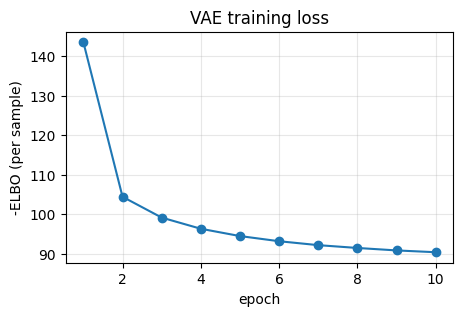

In [7]:
plt.figure(figsize=(5, 3))
plt.plot(range(1, len(vae_history) + 1), vae_history, marker="o")
plt.xlabel("epoch")
plt.ylabel("-ELBO (per sample)")
plt.title("VAE training loss")
plt.grid(alpha=0.3)
plt.show()

## 1-5. Reconstruction 확인

테스트 이미지를 넣어 복원 결과를 봅니다. 강의에서 언급한 "blurry" 특성이 실제로 보이는지 관찰하세요.

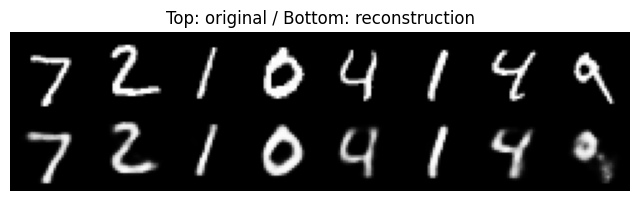

In [8]:
vae.eval()
x_test, _ = next(iter(test_loader))
x_test = x_test[:8].to(device)

with torch.no_grad():
    x_logit, _, _ = vae(x_test)
    x_recon = torch.sigmoid(x_logit).view(-1, 1, 28, 28)

pair = torch.cat([x_test.cpu(), x_recon.cpu()], dim=0)
show_images(pair, title="Top: original / Bottom: reconstruction", nrow=8)

## 1-6. TODO 4: Prior에서 생성

AE와 VAE의 결정적인 차이가 여기서 드러납니다.
VAE는 latent 분포를 $\mathcal{N}(0, I)$에 맞추도록 강제했기 때문에,
**학습 데이터를 전혀 거치지 않고** prior에서 $z$를 뽑아 decoder에 통과시키는 것만으로 새 이미지를 만들 수 있습니다.

- **TODO 4**: `N(0, I)`에서 `n_samples`개의 `z`를 뽑아 decoder에 넣고, `sigmoid`를 적용해 `[0, 1]` 이미지를 만드세요.

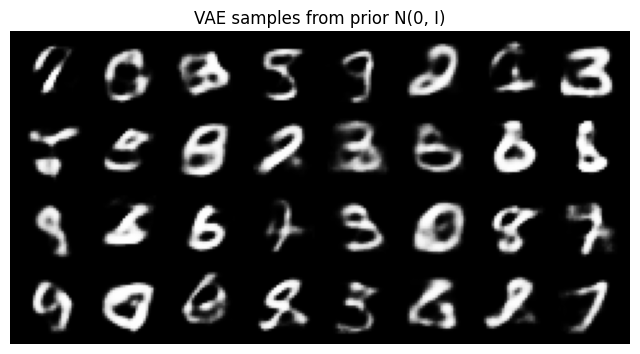

In [10]:
@torch.no_grad()
def vae_sample(model, n_samples=32):
    model.eval()
    # ------------------------------------------------------------------
    # TODO 4
    # 1) z ~ N(0, I),  shape = (n_samples, model.latent_dim), device 주의
    # 2) logit = model.decode(z)
    # 3) sigmoid 후 (n_samples, 1, 28, 28)로 reshape하여 반환
    z = torch.randn(n_samples, model.latent_dim, device=device)
    logit = model.decode(z)
    return torch.sigmoid(logit).view(n_samples, 1, 28, 28)
    
    # ------------------------------------------------------------------


vae_samples = vae_sample(vae, n_samples=32)
show_images(vae_samples, title="VAE samples from prior N(0, I)", nrow=8)

**Autoencoder** 는 encoder가 입력 $x$를 latent space의 하나의 점 $z$로 매핑합니다. 이때 $z$가 latent space의 어디에 위치하는지에 대한 제약이 전혀 없습니다. 학습이 끝나면 latent space 안에는 학습 데이터가 매핑된 점들이 여기저기 흩어져 있는데, 그 점들 사이에 빈 공간(hole), 밀도가 다른 영역, 정체를 알 수 없는 구조가 생깁니다. 그래서 아무 $z$나 뽑아서 decoder에 넣으면, 그 $z$가 학습 데이터가 실제로 매핑된 영역 근처인지 아닌지 보장할 수 없고, 대부분 decoder가 한 번도 보지 못한 영역이라 의미 없는 이미지가 나옵니다. 즉 AE는 생성 모델로 쓰기 어렵습니다 — sampling할 수 있는 분포 자체가 정의되어 있지 않기 때문입니다.

VAE는 여기서 근본적으로 다른 걸 합니다. encoder가 $x$를 점 하나로 보내는 게 아니라 분포 $q_\phi(z|x) = \mathcal{N}(\mu, \sigma^2)$로 보내고, loss에 KL term을 추가해서 이 분포가 $p(z) = \mathcal{N}(0, I)$에 가깝도록 강제합니다 (TODO 3에서 구현한 kl 항, 즉 regularization term이 바로 이 역할입니다). 학습이 끝나면:

모든 데이터 $x$에 대한 posterior $q_\phi(z|x)$들이 원점 근처의 $N(0, I)$ 안에 뭉쳐있게 되고,
latent space 전체가 구멍 없이 채워지도록 정규화되어, $N(0, I)$에서 뽑은 임의의 점 근처에도 항상 어떤 학습 데이터의 posterior가 걸쳐 있게 됩니다.
그 결과 decoder 관점에서는 $N(0, I)$에서 뽑은 $z$가 학습 중에 실제로 봤던 영역과 통계적으로 구분되지 않습니다. 그래서 학습 데이터 $x$를 전혀 거치지 않고, encoder도 아예 쓰지 않고, prior $N(0, I)$에서 바로 $z$를 뽑아 decoder만 통과시켜도 그럴듯한 새 이미지가 나오는 것입니다. 


## 1-7. Latent space interpolation (실행만)

두 이미지의 latent를 선형 보간하면서 decoder를 통과시킵니다.
latent space가 의미 있게 연속적으로 구성되었다면 중간 결과도 자연스러운 숫자 모양을 유지합니다.

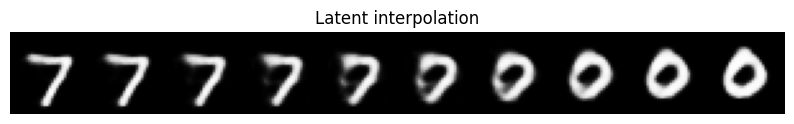

In [11]:
@torch.no_grad()
def interpolate(model, x1, x2, steps=10):
    model.eval()
    mu1, _ = model.encode(x1.view(1, -1).to(device))
    mu2, _ = model.encode(x2.view(1, -1).to(device))
    alphas = torch.linspace(0, 1, steps, device=device).unsqueeze(1)
    z = (1 - alphas) * mu1 + alphas * mu2
    return torch.sigmoid(model.decode(z)).view(-1, 1, 28, 28)


x_a, x_b = x_test[0].cpu(), x_test[3].cpu()
show_images(interpolate(vae, x_a, x_b, steps=10), title="Latent interpolation", nrow=10)

---
# Part 2. Diffusion (DDPM)

## 2-1. 무엇을 구현하는가

**Forward process**: 원본 $x_0$에 $T$번에 걸쳐 조금씩 Gaussian noise를 주입합니다.
학습된 파라미터가 없는, 미리 정해진 과정입니다.

$$
q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t; \sqrt{1-\beta_t}\,x_{t-1},\; \beta_t I\right)
$$

한 스텝씩 가는 대신, reparameterization을 반복 적용하면 임의의 $t$로 **한 번에** 점프할 수 있습니다.

$$
q(x_t \mid x_0) = \mathcal{N}\!\left(x_t; \sqrt{\bar\alpha_t}\,x_0,\; (1-\bar\alpha_t) I\right),
\qquad \alpha_t = 1 - \beta_t,\quad \bar\alpha_t = \prod_{s=1}^{t}\alpha_s
$$

**Reverse process**: 모델 $\epsilon_\theta(x_t, t)$는 "$x_t$에 섞여 있는 noise가 무엇이었는지"를 맞춥니다.
DDPM 논문의 단순화된 목적함수는 다음과 같습니다.

$$
\mathcal{L}_{\text{simple}} = \mathbb{E}_{t, x_0, \epsilon}\left[\left\| \epsilon - \epsilon_\theta\!\left(\sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,\; t\right) \right\|^2 \right]
$$

## 2-2. TODO 5: Noise schedule

- **TODO 5**: `betas`로부터 `alphas`와 `alphas_cumprod`($\bar\alpha_t$)를 계산하세요.
  누적곱은 `torch.cumprod`를 사용합니다.

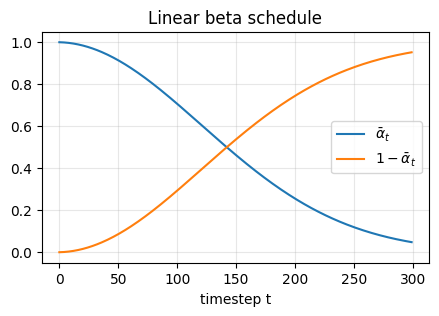

alpha_bar_0 = 0.9998999834060669 | alpha_bar_T = 0.04805842787027359


In [12]:
T = DIFF_TIMESTEPS

betas = torch.linspace(1e-4, 0.02, T)          # linear schedule

# ----------------------------------------------------------------------
# TODO 5
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)      # alpha_bar_t = prod_{s=1}^{t} alpha_s

# ----------------------------------------------------------------------

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

betas = betas.to(device)
alphas = alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)
sqrt_recip_alphas = sqrt_recip_alphas.to(device)

plt.figure(figsize=(5, 3))
plt.plot(alphas_cumprod.cpu(), label=r"$\bar{\alpha}_t$")
plt.plot((1 - alphas_cumprod).cpu(), label=r"$1-\bar{\alpha}_t$")
plt.xlabel("timestep t")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Linear beta schedule")
plt.show()

print("alpha_bar_0 =", alphas_cumprod[0].item(), "| alpha_bar_T =", alphas_cumprod[-1].item())

## 2-3. TODO 6: Forward process

- **TODO 6**: closed form을 그대로 코드로 옮기세요.
  $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon$

`extract`는 배치 안의 샘플마다 서로 다른 $t$에 해당하는 계수를 뽑아
`(B, 1, 1, 1)` 모양으로 broadcast할 수 있게 만들어 주는 헬퍼입니다.

In [13]:
def extract(a, t, x_shape):
    # a: (T,) 형태의 스케줄 텐서, t: (B,) 형태의 timestep 인덱스
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))
'''
왜 이게 필요한가: sqrt_alphas_cumprod 같은 스케줄 텐서는 (T,) shape, 즉 timestep 0부터 T-1까지 각각의 계수값을 담은 1차원 배열입니다. 
그런데 학습 루프(TODO 7)에서는 배치 안의 샘플마다 서로 다른 랜덤 t를 뽑습니다 (t는 (B,) shape). 
즉 샘플 0은 t=150, 샘플 1은 t=37, ... 이런 식으로 배치마다 다른 시점의 계수를 써야 합니다. 
그리고 이 계수를 x_0(shape (B, 1, 28, 28))에 곱하려면 broadcasting이 되도록 (B, 1, 1, 1) shape으로 맞춰줘야 합니다. 
extract가 이 두 가지(배치별로 다른 인덱스에서 값 뽑기 + broadcast 가능한 shape으로 reshape)를 처리하는 헬퍼입니다.
'''


def q_sample(x_0, t, noise=None):
    # x_0: (B, 1, 28, 28), 값 범위 [-1, 1]
    # t:   (B,) long tensor
    if noise is None:
        noise = torch.randn_like(x_0)

    # ------------------------------------------------------------------
    # TODO 6
    # 힌트:
    a = extract(sqrt_alphas_cumprod, t, x_0.shape)
    b = extract(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    return a*x_0 + b*noise
    # ------------------------------------------------------------------

### 확인

여러 timestep에서 forward process를 적용해 봅니다.
$t$가 커질수록 원본이 사라지고, $t = T-1$에서는 사실상 $\mathcal{N}(0, I)$에 가까워져야 합니다.

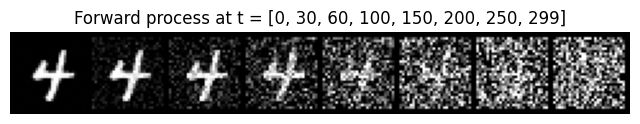

x_T mean = -0.1681 (target 0)
x_T std  = 0.9870 (target 1)


In [14]:
x0, _ = next(iter(diff_loader))
x0 = x0[:1].to(device)

steps = [0, 30, 60, 100, 150, 200, 250, T - 1]
imgs = []
for s in steps:
    t = torch.full((1,), s, device=device, dtype=torch.long)
    xt = q_sample(x0, t)
    imgs.append(((xt + 1) / 2).cpu())        # [-1,1] -> [0,1]

show_images(torch.cat(imgs, dim=0), title=f"Forward process at t = {steps}", nrow=len(steps))

# t = T-1 에서의 통계량이 표준정규에 가까운지 확인
t_last = torch.full((256,), T - 1, device=device, dtype=torch.long)
x_last = q_sample(x0.repeat(256, 1, 1, 1), t_last)
print(f"x_T mean = {x_last.mean().item():.4f} (target 0)")
print(f"x_T std  = {x_last.std().item():.4f} (target 1)")

## 2-4. Noise prediction 모델 (실행만)

$\epsilon_\theta(x_t, t)$ 역할을 할 작은 U-Net입니다.
timestep $t$는 sinusoidal embedding을 거쳐 각 block에 더해집니다.
**이 셀은 수정하지 않고 그대로 실행하면 됩니다.**

한 가지만 짚고 넘어가면, 모든 timestep에 대해 **하나의 네트워크**를 공유합니다.
$t$를 입력으로 넣어 주기 때문에 가능한 설계입니다.

In [15]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.norm2(self.conv2(h)))
        return h


class SimpleUNet(nn.Module):
    def __init__(self, base=32, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.down1 = ConvBlock(1, base, time_dim)              # 28x28
        self.pool1 = nn.MaxPool2d(2)                           # 14x14
        self.down2 = ConvBlock(base, base * 2, time_dim)       # 14x14
        self.pool2 = nn.MaxPool2d(2)                           # 7x7
        self.mid = ConvBlock(base * 2, base * 2, time_dim)     # 7x7
        self.up2 = nn.ConvTranspose2d(base * 2, base * 2, 2, 2)
        self.dec2 = ConvBlock(base * 4, base, time_dim)        # 14x14
        self.up1 = nn.ConvTranspose2d(base, base, 2, 2)
        self.dec1 = ConvBlock(base * 2, base, time_dim)        # 28x28
        self.out = nn.Conv2d(base, 1, 1)

    def forward(self, x, t):
        temb = self.time_mlp(t)
        d1 = self.down1(x, temb)
        d2 = self.down2(self.pool1(d1), temb)
        m = self.mid(self.pool2(d2), temb)
        u2 = self.dec2(torch.cat([self.up2(m), d2], dim=1), temb)
        u1 = self.dec1(torch.cat([self.up1(u2), d1], dim=1), temb)
        return self.out(u1)


unet = SimpleUNet().to(device)
n_params = sum(p.numel() for p in unet.parameters())
print(f"parameters: {n_params:,}")

with torch.no_grad():
    dummy_x = torch.randn(4, 1, 28, 28, device=device)
    dummy_t = torch.randint(0, T, (4,), device=device)
    print("output shape:", unet(dummy_x, dummy_t).shape)

parameters: 296,129
output shape: torch.Size([4, 1, 28, 28])


## 2-5. TODO 7: Loss

- **TODO 7**: $\mathcal{L}_{\text{simple}}$을 구현하세요.
  1. 배치의 각 샘플마다 $t \sim \text{Uniform}\{0, \dots, T-1\}$를 뽑는다
  2. $\epsilon \sim \mathcal{N}(0, I)$를 뽑는다
  3. `q_sample`로 $x_t$를 만든다
  4. 모델이 예측한 $\hat\epsilon$과 실제 $\epsilon$ 사이의 MSE를 계산한다

3번에서 **같은 `noise`를 넘겨줘야** 정답과 예측을 비교할 수 있습니다. 이 부분을 놓치지 마세요.

In [16]:
def diffusion_loss(model, x_0):
    # x_0: (B, 1, 28, 28), 값 범위 [-1, 1]
    B = x_0.size(0)

    # ------------------------------------------------------------------
    # TODO 7
    t = torch.randint(0, T, (B,), device=x_0.device, dtype=torch.long)           # (B,) long tensor, torch.randint 사용, device 주의
    noise = torch.randn_like(x_0)       # torch.randn_like(x_0)
    x_t = q_sample(x_0, t, noise=noise)         # q_sample(...)  <- 위에서 만든 noise를 그대로 넘길 것
    pred_noise = model(x_t, t)  # model(x_t, t)
    loss = F.mse_loss(pred_noise, noise)        # F.mse_loss
    
    # ------------------------------------------------------------------

    return loss

## 2-6. 학습

VAE보다 오래 걸립니다. GPU 기준 epoch당 30초 내외, CPU라면 훨씬 느리므로 `SUBSET_SIZE`를 줄이세요.

In [17]:
diff_opt = torch.optim.Adam(unet.parameters(), lr=2e-4)

diff_history = []
for epoch in range(1, DIFF_EPOCHS + 1):
    unet.train()
    running = 0.0
    t0 = time.time()

    for x, _ in diff_loader:
        x = x.to(device)
        loss = diffusion_loss(unet, x)

        diff_opt.zero_grad()
        loss.backward()
        diff_opt.step()

        running += loss.item()

    n = len(diff_loader)
    diff_history.append(running / n)
    print(f"[DDPM] epoch {epoch:02d}/{DIFF_EPOCHS} | loss {running/n:.5f} | {time.time()-t0:5.1f}s")

[DDPM] epoch 01/10 | loss 0.12031 |  26.2s
[DDPM] epoch 02/10 | loss 0.06312 |  25.6s
[DDPM] epoch 03/10 | loss 0.05677 |  25.6s
[DDPM] epoch 04/10 | loss 0.05369 |  25.5s
[DDPM] epoch 05/10 | loss 0.05121 |  25.5s
[DDPM] epoch 06/10 | loss 0.04995 |  25.7s
[DDPM] epoch 07/10 | loss 0.04877 |  25.5s
[DDPM] epoch 08/10 | loss 0.04769 |  25.7s
[DDPM] epoch 09/10 | loss 0.04678 |  25.5s
[DDPM] epoch 10/10 | loss 0.04676 |  25.6s


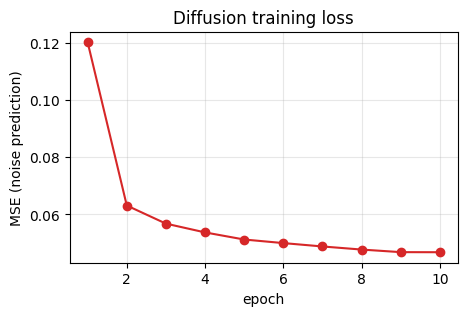

In [18]:
plt.figure(figsize=(5, 3))
plt.plot(range(1, len(diff_history) + 1), diff_history, marker="o", color="tab:red")
plt.xlabel("epoch")
plt.ylabel("MSE (noise prediction)")
plt.title("Diffusion training loss")
plt.grid(alpha=0.3)
plt.show()

## 2-7. TODO 8: Reverse denoising

순수 noise $x_T \sim \mathcal{N}(0, I)$에서 출발해 $t = T-1, \dots, 0$ 순서로 한 스텝씩 되돌립니다.
DDPM의 sampling 식은 다음과 같습니다.

$$
x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t, t)\right) + \sigma_t z,
\qquad z \sim \mathcal{N}(0, I)
$$

여기서 $\sigma_t = \sqrt{\beta_t}$를 사용하고, **$t = 0$일 때는 noise를 더하지 않습니다** ($z = 0$).

- **TODO 8**: 위 식에서 `model_mean` 부분(괄호 앞 전체)을 계산하세요.
  나머지 분기 처리는 이미 작성되어 있습니다.

In [19]:
@torch.no_grad()
def p_sample(model, x_t, t, t_index):
    betas_t = extract(betas, t, x_t.shape)
    sqrt_one_minus_t = extract(sqrt_one_minus_alphas_cumprod, t, x_t.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x_t.shape)

    pred_noise = model(x_t, t)

    # ------------------------------------------------------------------
    # TODO 8
    # model_mean = (1/sqrt(alpha_t)) * ( x_t - (beta_t / sqrt(1 - alpha_bar_t)) * pred_noise )
    model_mean = sqrt_recip_alphas_t * (x_t - betas_t / sqrt_one_minus_t*pred_noise)
    # ------------------------------------------------------------------

    if t_index == 0:
        return model_mean

    noise = torch.randn_like(x_t)
    return model_mean + torch.sqrt(betas_t) * noise


@torch.no_grad()
def p_sample_loop(model, n_samples=32, record_every=None):
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28, device=device)
    trajectory = []

    for i in reversed(range(T)):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        x = p_sample(model, x, t, i)
        if record_every is not None and (i % record_every == 0 or i == 0):
            trajectory.append(x.clone())

    return x, trajectory

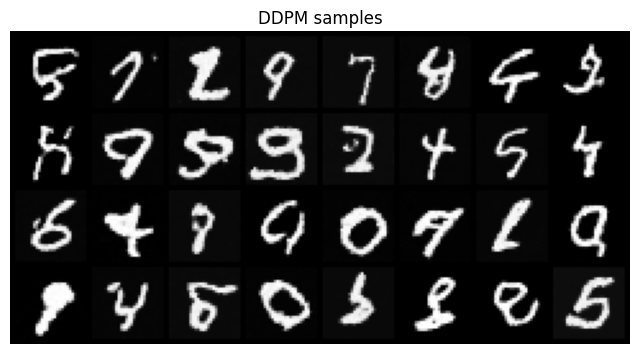

In [20]:
samples, traj = p_sample_loop(unet, n_samples=32, record_every=50)

show_images((samples + 1) / 2, title="DDPM samples", nrow=8)

### Denoising 과정 시각화

한 샘플이 noise에서 숫자로 변해 가는 궤적을 봅니다.

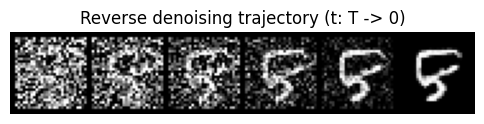

In [21]:
track = torch.cat([((s[0:1] + 1) / 2) for s in traj], dim=0)
show_images(track, title="Reverse denoising trajectory (t: T -> 0)", nrow=track.size(0))

---
# Part 3. 비교 및 서술형 질문

## 3-1. 두 모델 나란히 보기

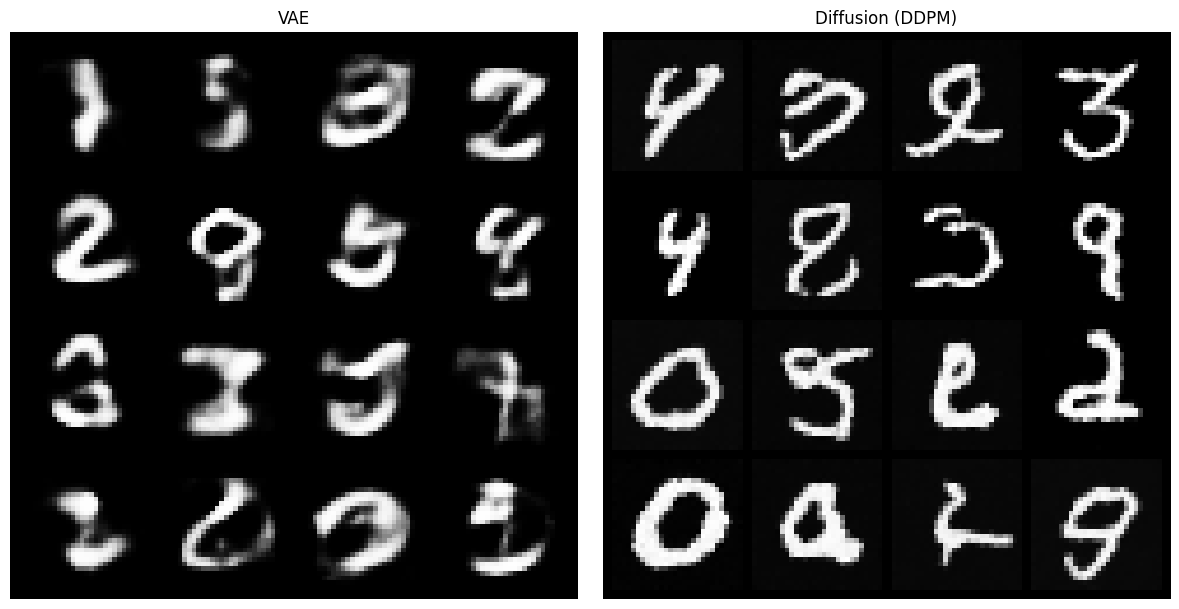

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

vae_grid = make_grid(vae_sample(vae, 16).cpu().clamp(0, 1), nrow=4, padding=2)
diff_grid = make_grid(((p_sample_loop(unet, 16)[0] + 1) / 2).cpu().clamp(0, 1), nrow=4, padding=2)

axes[0].imshow(vae_grid.permute(1, 2, 0).squeeze(), cmap="gray")
axes[0].set_title("VAE")
axes[0].axis("off")

axes[1].imshow(diff_grid.permute(1, 2, 0).squeeze(), cmap="gray")
axes[1].set_title("Diffusion (DDPM)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3-2. 서술형 질문

아래 셀에 직접 답변을 작성하세요. 정답을 맞히는 것보다 근거를 적는 것이 중요합니다.

**Q1.** 위에서 생성한 VAE 샘플과 Diffusion 샘플의 화질을 비교하고, 그 차이가 어디서 오는지 설명하세요.
강의 슬라이드 81~83쪽의 비교(single latent variable vs. markov chain으로 연결된 multiple latent variables)와
두 모델의 loss 구성(Regularization / Denoising / Reconstruction)을 근거로 삼으세요.

**Q2.** 학습이 끝난 뒤 이미지 한 장을 만드는 데 걸리는 시간을 두 모델에서 비교하면 어떤 차이가 있나요?
`T = 300`을 `T = 1000`으로 바꾸면 (a) 학습 시간과 (b) 샘플링 시간은 각각 어떻게 변할지, 그 이유와 함께 서술하세요.

### 답변

**Q1.**
VAE 샘플은 전체적으로 부드럽고 뭉개지고 윤곽선이 흐릿하며 숫자의 세부 디테일이 잘 살지 않음. 반면 Diffusion 샘플은 상대적으로 획의 경계가 뚜렷하고 다양한 필체 변형이 살아 있다. 이 차이는 두 모델이 latent 몇 개를 어떤 구조로 쓰는지, 그리고 loss가 어떤 제약을 거는지에서 직접적으로 나온다.

**Single latent variable (VAE) vs Markov chain of latents (Diffusion)**

- VAE는 이미지 하나를 만드는 데 필요한 모든 정보를 latent variable $z$ 하나에 압축한 뒤 decoder를 단 한 번 통과시켜 이미지 전체를 한 번에 복원한다. 이 한 번의 매핑이 감당해야 하는 정보량과 비선형성이 매우 크기 때문에 decoder는 여러 가능한 이미지들 사이의 평균적인 형태를 내놓는 경향이 생기고 이게 blur로 나타난다.
- 반면 Diffusion은 $x_0$(원본)에서 $x_T$(순수 노이즈)까지 이어지는 길게 연결된 Markov chain 위의 latent들($x_1, x_2, \dots, x_T$, T = DIFF_TIMESTEPS = 300)을 사용한다. 매 스텝마다 아주 작은 양의 노이즈($\beta_t$만큼)를 제거하는 훨씬 단순한 300개의 부분 문제로 분해했다. 그래서 각 스텝에서 모델이 표현해야 하는 조건부 분포가 훨씬 단순(거의 unimodal Gaussian에 가까움)해지고 그 결과 전체 reverse process를 거치며 고주파 디테일을 점진적으로 채워나갈 수 있다.

**Loss 구성 관점 (Regularization / Denoising / Reconstruction)**

- VAE의 loss는 Reconstruction(recon, BCEWithLogits)과 Regularization(kl, $q(z|x)$를 $N(0,I)$로 강제) 두 항의 합이다. 여기서 KL 항은 encoder가 만드는 posterior를 단 하나의 등방 Gaussian에 가깝게 만들도록 강하게 규제하는데, 이 규제가 latent $z$가 담을 수 있는 정보량 자체를 제한한다(정보량이 제한된 bottleneck). 동시에 픽셀 단위 독립 Bernoulli 가정(BCE)에 기반한 reconstruction term은, encoder의 posterior에 여전히 남아 있는 불확실성(같은 $x$에 대해 여러 그럴듯한 $z$가 가능함)을 decoder가 그 불확실성 하에서의 기대값으로 처리하게 만들어, 여러 그럴듯한 출력들을 평균 낸 것 같은 뭉개진 이미지를 만드는 유인이 생긴다.

- Diffusion의 loss는 Denoising 성격의 항 하나, 즉 $\mathbb{E}[|\epsilon - \epsilon_\theta(x_t,t)|^2]$뿐이다. 이 loss에는 VAE의 KL처럼 정보를 하나의 작은 벡터로 강제 압축하는 항이 없다. 대신 $T$개의 서로 다른 noise level에 대해 그 정도의 노이즈를 예측/제거하는 국소적인 작업만 반복해서 잘 하도록 학습되며, 이 국소적 작업들의 연쇄가 결과적으로 복잡하고 다양한 이미지 분포를 표현할 수 있게 해줍니다. 즉 VAE는 하나의 강한 정보량 제약(KL) 아래 한 번에 생성해야 해서 blur가 발생하고, Diffusion은 제약이 약한 대신 여러 단계에 걸쳐 점진적으로 세부를 채워나갈 수 있어 더 선명한 결과를 만든다.

**Q2.**

VAE는 생성 시(vae_sample) $z \sim N(0,I)$를 뽑은 뒤 model.decode(z)를 단 한 번 호출하면 끝이다. 즉 네트워크 forward pass가 1회다.

Diffusion은 p_sample_loop에서 보듯 $x_T$에서 시작해 for i in reversed(range(T)) 루프를 돌며 매 스텝마다 U-Net을 한 번씩 호출한다. 즉 이미지 한 장을 만드는 데 네트워크 forward pass가 $T$번 필요하다. 이는 VAE가 diffusion 모델보다 inference가 훨씬 빠르다고 알려진 이유이기도 하다.

T = 300 → T = 1000으로 바꿀 때

(a) 학습 시간: 거의 불변: diffusion_loss를 보면, 학습 스텝마다 배치의 각 샘플에 대해 $t$를 torch.randint(0, T, (B,))로 한 번만 뽑고, model도 한 번만 forward함— $t$의 범위가 0299에서 0999로 넓어질 뿐, 학습 루프가 $T$번 반복되는 구조가 아니다. 따라서 한 epoch당 forward/backward 횟수(= 배치 개수)는 그대로이고, betas, alphas_cumprod 등 스케줄 텐서를 만드는 비용(torch.linspace, torch.cumprod)도 $T$에 대해 선형이지만 학습 루프 밖에서 한 번만 계산되므로 무시할 수준이다. 즉 (a) 학습 시간은 거의 그대로

(b) 샘플링 시간: 거의 정확히 비례해서 늘어난다. p_sample_loop의 for i in reversed(range(T)) 루프가 T번 반복되며 매번 U-Net을 1회 호출하므로, 이미지 한 장을 만드는 데 필요한 forward pass 수가 $T$에 정확히 비례한다. T를 300 → 1000으로 늘리면 샘플링 시간은 대략 $1000/300 \approx 3.3$배로 늘어난다. 이는 diffusion 모델의 대표적인 단점(iterative sampling cost가 스텝 수에 선형으로 비례)으로, 실제로 DDIM 등 sampling 스텝을 줄이는 기법들이 이 문제를 해결하기 위해 제안된 배경이다.


---
## 제출 전 체크리스트

- [ ] TODO 1~8을 모두 채웠다
- [ ] `Runtime > Restart and run all`로 처음부터 끝까지 에러 없이 실행된다
- [ ] 출력(loss 로그, 이미지)이 노트북에 남아 있는 상태로 저장했다
- [ ] 서술형 Q1~Q2에 답변했다
- [ ] ELBO 손유도 `.pdf`를 함께 준비했다

`KUBIG_26_FALL/Basic Study/CV/week4`에 제출 / 마감 8/5(수) 자정